# Python-based graph representation analysis of RAC1-induced GRN rewiring

This notebook provides a supplementary Python analysis for the RAC1-LUAD perturbation-informed tumor-state mapping project.

The WT and RAC1-vKO GRN adjacency matrices used here were exported from the main R-based scTenifoldKnk workflow. Therefore, this analysis is not an independent data-source validation or an independent GRN inference workflow. Instead, it provides a secondary graph-based computational validation and representation-learning extension based on scTenifoldKnk-derived WT/vKO networks.

The goal is to test whether RAC1-responsive differentially rewired genes (DR genes), identified by scTenifoldKnk, also show larger network-role or graph-representation shifts between WT and RAC1-vKO GRN spaces when quantified using Python-based graph analysis methods.

The analysis includes three complementary graph-based layers:

1. Network topology shift validation
2. Adjacency-vector PCA graph representation shift validation
3. Aligned node2vec embedding shift validation

Together, these analyses evaluate whether RAC1-responsive DR genes are not only ranked highly by scTenifoldKnk perturbation distance, but also occupy more shifted positions in WT versus RAC1-vKO graph representation spaces.


## 1. Input loading and data inspection

This section uploads and extracts the input files exported from the R workflow, then loads WT and RAC1-vKO GRN matrices, RAC1 DR genes, and the GRN gene list using pandas.

The input files include:

* `WT_GRN_matrix.csv`
* `RAC1_vKO_GRN_matrix.csv`
* `RAC1_TopDRgenes.csv`
* `GRN_gene_list.csv`



In [1]:
from google.colab import files
uploaded = files.upload()

Saving python_inputs.zip to python_inputs (1).zip


In [2]:
import zipfile
import os

zip_path = "python_inputs.zip"
extract_dir = "python_inputs"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

os.listdir(extract_dir)

['RAC1_vKO_GRN_matrix.csv',
 'GRN_gene_list.csv',
 'WT_GRN_matrix.csv',
 'RAC1_TopDRgenes.csv']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

WT = pd.read_csv("python_inputs/WT_GRN_matrix.csv", index_col=0)
vKO = pd.read_csv("python_inputs/RAC1_vKO_GRN_matrix.csv", index_col=0)
DR = pd.read_csv("python_inputs/RAC1_TopDRgenes.csv")
gene_list = pd.read_csv("python_inputs/GRN_gene_list.csv")

print("WT shape:", WT.shape)
print("vKO shape:", vKO.shape)
print("DR shape:", DR.shape)
print("gene_list shape:", gene_list.shape)

WT shape: (366, 366)
vKO shape: (366, 366)
DR shape: (100, 6)
gene_list shape: (366, 1)


## 2. Matrix consistency and gene mapping checks

This section checks whether WT and RAC1-vKO matrices have matched gene orders, whether RAC1 is present in the GRN, and whether RAC1-responsive DR genes can be mapped to the network gene set.

These checks are necessary before comparing WT and RAC1-vKO graph representations.


In [4]:
# 查看WT和RAC1-vKO矩阵的左上角5×5
display(WT.iloc[:5, :5])
display(vKO.iloc[:5, :5])

# 查看DR gene前5行
display(DR.head())
display(gene_list.head())

,IGF2,SCGB1A1,KRT81,NTS,PSCA
IGF2,0.000,0,0.000,0.008,0.000
SCGB1A1,0.000,0,0.000,0.000,0.000
KRT81,0.000,0,0.000,0.001,0.002
NTS,0.005,0,0.001,0.000,-0.001
PSCA,0.000,0,0.002,-0.001,0.000


,IGF2,SCGB1A1,KRT81,NTS,PSCA
IGF2,0.000,0,0.000,0.008,0.000
SCGB1A1,0.000,0,0.000,0.000,0.000
KRT81,0.000,0,0.000,0.001,0.002
NTS,0.005,0,0.001,0.000,-0.001
PSCA,0.000,0,0.002,-0.001,0.000


,gene,distance,Z,FC,p.value,p.adj
0,RAC1,0.001713,5.138176,18623.597420,0.000000e+00,0.000000e+00
1,SFTPA1,0.000075,2.241167,35.325681,2.789297e-09,5.104414e-07
2,SFTPA2,0.000070,2.198307,31.364424,2.138640e-08,2.609140e-06
3,PLAT,0.000066,2.154189,27.719240,1.402608e-07,1.283386e-05
4,SFTPB,0.000064,2.125926,25.594393,4.212618e-07,3.083636e-05


,gene
0,IGF2
1,SCGB1A1
2,KRT81
3,NTS
4,PSCA


In [5]:
# 检查WT和vKO的行列名是否一致
same_row_order = list(WT.index) == list(vKO.index)
same_col_order = list(WT.columns) == list(vKO.columns)

same_wt_row_col = list(WT.index) == list(WT.columns)
same_vko_row_col = list(vKO.index) == list(vKO.columns)

print("Same row order between WT and vKO:", same_row_order)
print("Same column order between WT and vKO:", same_col_order)
print("WT row names == WT column names:", same_wt_row_col)
print("vKO row names == vKO column names:", same_vko_row_col)

Same row order between WT and vKO: True
Same column order between WT and vKO: True
WT row names == WT column names: True
vKO row names == vKO column names: True


In [6]:
# 网络中的所有基因
network_genes = set(WT.index)

# DR表中的所有基因
dr_genes = set(DR["gene"])

# 检查 RAC1 是否存在
print("RAC1 in network:", "RAC1" in network_genes)
print("RAC1 in DR table:", "RAC1" in dr_genes)

# 检查DR genes有多少能匹配到网络中
dr_in_network = dr_genes & network_genes
dr_not_in_network = dr_genes - network_genes

print("Number of DR genes:", len(dr_genes))
print("DR genes in network:", len(dr_in_network))
print("DR genes NOT in network:", len(dr_not_in_network))

print("Example DR genes in network:")
print(list(dr_in_network)[:10])

print("Example DR genes NOT in network:")
print(list(dr_not_in_network)[:10])

RAC1 in network: True
RAC1 in DR table: True
Number of DR genes: 100
DR genes in network: 100
DR genes NOT in network: 0
Example DR genes in network:
['CST6', 'IL32', 'CRIP2', 'PTPN13', 'ANKRD36C', 'SFTPA2', 'RND3', 'C3', 'NINJ2', 'HLA-DPA1']
Example DR genes NOT in network:
[]


In [7]:
print("WT data type summary:")
print(WT.dtypes.value_counts())

print("\nvKO data type summary:")
print(vKO.dtypes.value_counts())

print("\nAny NA in WT:", WT.isna().sum().sum())
print("Any NA in vKO:", vKO.isna().sum().sum())

WT data type summary:
float64    348
int64       18
Name: count, dtype: int64

vKO data type summary:
float64    348
int64       18
Name: count, dtype: int64

Any NA in WT: 0
Any NA in vKO: 0


## 3. Weighted GRN graph construction

This section converts WT and RAC1-vKO GRN adjacency matrices into weighted NetworkX graphs.

Because the original matrices are dense gene-by-gene regulatory networks, only the top 5% strongest absolute-weight edges are retained to construct comparable sparse graph representations. Nodes represent genes, edges represent inferred regulatory relationships, and edge weights represent regulatory connection strengths.

This graph construction step is based on scTenifoldKnk-derived WT and RAC1-vKO networks, rather than independent GRN inference.

In [8]:
import networkx as nx

# 1.转成float，避免int/float混合
WT_mat = WT.astype(float)
vKO_mat = vKO.astype(float)

# 2.对称化，构建undirected graph
WT_mat = (WT_mat + WT_mat.T) / 2
vKO_mat = (vKO_mat + vKO_mat.T) / 2

# 3.去掉自连接
np.fill_diagonal(WT_mat.values, 0)
np.fill_diagonal(vKO_mat.values, 0)

print("WT_mat shape:", WT_mat.shape)
print("vKO_mat shape:", vKO_mat.shape)

print("WT min:", WT_mat.values.min(), "WT max:", WT_mat.values.max())
print("vKO min:", vKO_mat.values.min(), "vKO max:", vKO_mat.values.max())

print("WT diagonal sum:", np.diag(WT_mat).sum())
print("vKO diagonal sum:", np.diag(vKO_mat).sum())

WT_mat shape: (366, 366)
vKO_mat shape: (366, 366)
WT min: -0.5505 WT max: 0.9425
vKO min: -0.5505 vKO max: 0.9425
WT diagonal sum: 0.0
vKO diagonal sum: 0.0


In [9]:
# 检查WT和vKO是否完全相同
same_matrix = np.allclose(WT_mat.values, vKO_mat.values)

# 计算vKO-WT的差异矩阵
delta_mat = vKO_mat - WT_mat

print("WT and vKO matrices exactly / nearly identical:", same_matrix)

print("Delta matrix shape:", delta_mat.shape)
print("Delta min:", delta_mat.values.min())
print("Delta max:", delta_mat.values.max())
print("Delta mean:", delta_mat.values.mean())
print("Delta absolute mean:", np.abs(delta_mat.values).mean())
print("Number of non-zero delta entries:", np.sum(np.abs(delta_mat.values) > 1e-12))

WT and vKO matrices exactly / nearly identical: False
Delta matrix shape: (366, 366)
Delta min: -0.262
Delta max: 0.179
Delta mean: -0.000136873301681149
Delta absolute mean: 0.0002477604586580669
Number of non-zero delta entries: 684


In [10]:
# 提取矩阵上三角部分，避免重复计算A-B和B-A
upper_idx = np.triu_indices_from(WT_mat.values, k=1)
WT_weights = WT_mat.values[upper_idx]
vKO_weights = vKO_mat.values[upper_idx]

WT_abs = np.abs(WT_weights)
vKO_abs = np.abs(vKO_weights)

print("Number of possible gene-gene edges:", len(WT_abs))

print("\nWT absolute weight quantiles:")
print(pd.Series(WT_abs).quantile([0, 0, 0.9, 0.95, 0.99, 1]))

print("\nvKO absolute weight quantiles:")
print(pd.Series(vKO_abs).quantile([0, 0.5, 0.9, 0.95, 0.99, 1]))

Number of possible gene-gene edges: 66795

WT absolute weight quantiles:
0.00    0.0000
0.00    0.0000
0.90    0.1525
0.95    0.2470
0.99    0.4570
1.00    0.9425
dtype: float64

vKO absolute weight quantiles:
0.00    0.00000
0.50    0.01200
0.90    0.15150
0.95    0.24600
0.99    0.45653
1.00    0.94250
dtype: float64


In [11]:
def matrix_to_graph(adj_matrix, top_fraction=0.05):
    """
    Convert an adjacency matrix into an undirected weighted NetworkX graph.

    Parameters
    ----------
    adj_matrix : pandas DataFrame
        Gene × gene adjacency matrix.
    top_fraction : float
        Fraction of strongest absolute-weight edges to keep.

    Returns
    -------
    G : networkx.Graph
        Weighted undirected graph.
    cutoff : float
        Absolute weight cutoff used for edge filtering.
    """

    genes = list(adj_matrix.index)
    values = adj_matrix.values

    # 只取上三角，避免重复
    rows, cols = np.triu_indices_from(values, k=1)
    edge_weights = values[rows, cols]
    abs_weights = np.abs(edge_weights)

    # 计算保留top_fraction边的cutoff
    n_possible_edges = len(abs_weights)
    n_keep = int(np.ceil(top_fraction * n_possible_edges))
    cutoff = np.sort(abs_weights)[-n_keep]

    # 创建空图
    G = nx.Graph()
    G.add_nodes_from(genes)

    # 添加边
    for i, j, w, aw in zip(rows, cols, edge_weights, abs_weights):
        if aw >= cutoff and aw > 0:
            G.add_edge(
                genes[i],
                genes[j],
                weight=float(w),
                abs_weight=float(aw),
                sign=int(np.sign(w))
            )

    return G, cutoff

In [12]:
WT_graph, WT_cutoff = matrix_to_graph(WT_mat, top_fraction=0.05)
vKO_graph, vKO_cutoff = matrix_to_graph(vKO_mat, top_fraction=0.05)

print("WT graph:")
print("Number of nodes:", WT_graph.number_of_nodes())
print("Number of edges:", WT_graph.number_of_edges())
print("Weight cutoff:", WT_cutoff)

print("\nvKO graph:")
print("Number of nodes:", vKO_graph.number_of_nodes())
print("Number of edges:", vKO_graph.number_of_edges())
print("Weight cutoff:", vKO_cutoff)

WT graph:
Number of nodes: 366
Number of edges: 3361
Weight cutoff: 0.247

vKO graph:
Number of nodes: 366
Number of edges: 3351
Weight cutoff: 0.246


In [13]:
def basic_graph_stats(G, graph_name):
    """
    Print basic graph statistics.
    """
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)

    components = list(nx.connected_components(G))
    n_components = len(components)
    largest_component_size = max(len(c) for c in components)

    degrees = dict(G.degree())
    avg_degree = np.mean(list(degrees.values()))

    abs_weights = [data["abs_weight"] for _, _, data in G.edges(data=True)]
    avg_abs_weight = np.mean(abs_weights)

    print(f"===== {graph_name} =====")
    print("Number of nodes:", n_nodes)
    print("Number of edges:", n_edges)
    print("Density:", round(density, 4))
    print("Number of connected components:", n_components)
    print("Largest component size:", largest_component_size)
    print("Average degree:", round(avg_degree, 3))
    print("Average absolute edge weight:", round(avg_abs_weight, 6))
    print()

basic_graph_stats(WT_graph, "WT GRN")
basic_graph_stats(vKO_graph, "RAC1-vKO GRN")

===== WT GRN =====
Number of nodes: 366
Number of edges: 3361
Density: 0.0503
Number of connected components: 168
Largest component size: 199
Average degree: 18.366
Average absolute edge weight: 0.373509

===== RAC1-vKO GRN =====
Number of nodes: 366
Number of edges: 3351
Density: 0.0502
Number of connected components: 168
Largest component size: 199
Average degree: 18.311
Average absolute edge weight: 0.373051



## 4. Network topology shift validation

This section evaluates whether RAC1-responsive DR genes show larger network-role changes between WT and RAC1-vKO GRNs than non-DR genes.

For each gene, several topology metrics are calculated in both graphs, including degree centrality, weighted strength, betweenness centrality, and weighted clustering coefficient. A composite topology shift score is then calculated from the scaled changes of these metrics.

RAC1 itself is excluded from DR versus non-DR group comparisons to avoid a trivial effect from the virtual knockout target.

In [14]:
# Add distance attribute for weighted shortest-path based metrics
# Stronger edge=shorter distance

for G in [WT_graph, vKO_graph]:
    for u, v, data in G.edges(data=True):
        data["distance"] = 1 / (data["abs_weight"] + 1e-9)

print("Distance attribute added.")

Distance attribute added.


In [15]:
def calculate_node_metrics(G, graph_name):
    """
    Calculate node-level topology metrics for a weighted GRN graph.
    """

    # 1.degree centrality
    degree_centrality = nx.degree_centrality(G)

    # 2.strength
    strength = {}
    for node in G.nodes():
        total_weight = 0
        for _, _, edge_data in G.edges(node, data=True):
            total_weight += edge_data["abs_weight"]
        strength[node] = total_weight

    # 3.betweenness centrality
    betweenness = nx.betweenness_centrality(
        G,
        weight="distance",
        normalized=True
    )

    # 4.weighted clustering coefficient
    clustering = nx.clustering(
        G,
        weight="abs_weight"
    )

    metrics_df = pd.DataFrame({
        "gene": list(G.nodes()),
        f"degree_centrality_{graph_name}": [degree_centrality[g] for g in G.nodes()],
        f"strength_{graph_name}": [strength[g] for g in G.nodes()],
        f"betweenness_{graph_name}": [betweenness[g] for g in G.nodes()],
        f"clustering_{graph_name}": [clustering[g] for g in G.nodes()]
    })

    return metrics_df

WT_metrics = calculate_node_metrics(WT_graph, "WT")
vKO_metrics = calculate_node_metrics(vKO_graph, "vKO")

display(WT_metrics.head())
display(vKO_metrics.head())

,gene,degree_centrality_WT,strength_WT,betweenness_WT,clustering_WT
0,IGF2,0.000000,0.0000,0.0,0.000000
1,SCGB1A1,0.000000,0.0000,0.0,0.000000
2,KRT81,0.000000,0.0000,0.0,0.000000
3,NTS,0.093151,10.1505,0.0,0.373235
4,PSCA,0.000000,0.0000,0.0,0.000000


,gene,degree_centrality_vKO,strength_vKO,betweenness_vKO,clustering_vKO
0,IGF2,0.000000,0.0000,0.0,0.000000
1,SCGB1A1,0.000000,0.0000,0.0,0.000000
2,KRT81,0.000000,0.0000,0.0,0.000000
3,NTS,0.093151,10.1505,0.0,0.373235
4,PSCA,0.000000,0.0000,0.0,0.000000


In [16]:
# Merge WT and vKO metrics by gene
topology_df = WT_metrics.merge(vKO_metrics, on="gene")

metric_names = [
    "degree_centrality",
    "strength",
    "betweenness",
    "clustering"
]

# Calculate raw and scaled shifts
for metric in metric_names:
    wt_col = f"{metric}_WT"
    vko_col = f"{metric}_vKO"

    # raw difference
    topology_df[f"{metric}_delta"] = topology_df[vko_col] - topology_df[wt_col]
    topology_df[f"{metric}_abs_delta"] = np.abs(topology_df[f"{metric}_delta"])

    # scale by global standard deviation across WT and vKO values
    combined_values = pd.concat([topology_df[wt_col], topology_df[vko_col]])
    metric_sd = combined_values.std()

    topology_df[f"{metric}_scaled_delta"] = topology_df[f"{metric}_delta"] / metric_sd

# Overall topology shift score
scaled_delta_cols = [f"{m}_scaled_delta" for m in metric_names]

topology_df["topology_shift"] = np.sqrt(
    np.sum(topology_df[scaled_delta_cols] ** 2, axis=1)
)

# Mark DR genes
dr_genes_no_rac1 = set(DR["gene"]) - {"RAC1"}

topology_df["is_DR_gene"] = topology_df["gene"].isin(dr_genes_no_rac1)
topology_df["is_RAC1"] = topology_df["gene"] == "RAC1"

# View top shifted genes
topology_df_sorted = topology_df.sort_values("topology_shift", ascending=False)

display(topology_df_sorted.head(15))

,gene,degree_centrality_WT,strength_WT,betweenness_WT,clustering_WT,degree_centrality_vKO,strength_vKO,betweenness_vKO,clustering_vKO,degree_centrality_delta,...,strength_scaled_delta,betweenness_delta,betweenness_abs_delta,betweenness_scaled_delta,clustering_delta,clustering_abs_delta,clustering_scaled_delta,topology_shift,is_DR_gene,is_RAC1
302,RAC1,0.106849,12.4215,0.000000,0.252768,0.002740,0.2580,0.000000,0.000000,-0.104110,...,-1.268503,0.000000,0.000000,0.000000,-0.252768,0.252768,-1.434085,2.500738,False,True
70,PLAU,0.005479,0.5845,0.000000,0.396575,0.008219,0.8310,0.000000,0.371349,0.002740,...,0.025707,0.000000,0.000000,0.000000,-0.025225,0.025225,-0.143117,0.151445,True,False
95,CDKN2A,0.230137,37.2770,0.098796,0.154002,0.230137,37.0150,0.099895,0.150494,0.000000,...,-0.027323,0.001099,0.001099,0.141325,-0.003508,0.003508,-0.019904,0.145311,True,False
312,NAPSA,0.200000,31.6135,0.071609,0.134573,0.197260,31.2565,0.070661,0.137163,-0.002740,...,-0.037231,-0.000948,0.000948,-0.121965,0.002590,0.002590,0.014696,0.135166,True,False
107,TUBA1B,0.104110,12.3375,0.000000,0.268572,0.109589,12.8295,0.000000,0.257847,0.005479,...,0.051310,0.000000,0.000000,0.000000,-0.010726,0.010726,-0.060854,0.116210,False,False
72,SFTPD,0.134247,19.0725,0.000000,0.205336,0.139726,19.5130,0.000000,0.194186,0.005479,...,0.045939,0.000000,0.000000,0.000000,-0.011150,0.011150,-0.063261,0.115244,True,False
125,ANXA1,0.175342,23.9615,0.000933,0.215706,0.180822,24.4545,0.000948,0.208420,0.005479,...,0.051414,0.000015,0.000015,0.001936,-0.007286,0.007286,-0.041337,0.107354,False,False
128,HLA-DPA1,0.043836,4.5880,0.000000,0.344694,0.046575,4.8340,0.000000,0.328918,0.002740,...,0.025655,0.000000,0.000000,0.000000,-0.015775,0.015775,-0.089502,0.102280,True,False
7,S100A2,0.016438,1.6975,0.000000,0.418979,0.019178,1.9435,0.000000,0.405178,0.002740,...,0.025655,0.000000,0.000000,0.000000,-0.013801,0.013801,-0.078301,0.092636,True,False
320,CYR61,0.008219,0.7905,0.000000,0.332822,0.010959,1.0370,0.000000,0.346225,0.002740,...,0.025707,0.000000,0.000000,0.000000,0.013403,0.013403,0.076042,0.090750,False,False


In [17]:
from scipy.stats import mannwhitneyu

# Exclude RAC1 from group comparison
comparison_df = topology_df[topology_df["gene"] != "RAC1"].copy()
dr_shift = comparison_df.loc[
    comparison_df["is_DR_gene"],
    "topology_shift"
]
non_dr_shift = comparison_df.loc[
    ~comparison_df["is_DR_gene"],
    "topology_shift"
]

print("Number of DR genes excluding RAC1:", len(dr_shift))
print("Number of non-DR genes:", len(non_dr_shift))

print("\nDR topology shift summary:")
print(dr_shift.describe())

print("\nNon-DR topology shift summary:")
print(non_dr_shift.describe())

# Mann-Whitney U test
# alternative="greater" means: testing whether DR genes have larger topology shift
u_stat, p_value = mannwhitneyu(
    dr_shift,
    non_dr_shift,
    alternative="greater"
)

print("\nMann-Whitney U statistic:", u_stat)
print("P value:", p_value)

Number of DR genes excluding RAC1: 99
Number of non-DR genes: 266

DR topology shift summary:
count    99.000000
mean      0.031099
std       0.037510
min       0.000000
25%       0.000000
50%       0.007286
75%       0.058407
max       0.151445
Name: topology_shift, dtype: float64

Non-DR topology shift summary:
count    266.000000
mean       0.008034
std        0.020660
min        0.000000
25%        0.000000
50%        0.000000
75%        0.003072
max        0.116210
Name: topology_shift, dtype: float64

Mann-Whitney U statistic: 18003.5
P value: 1.0966385220528591e-10


In [18]:
# Prepare plotting dataframe
plot_df = comparison_df.copy()

plot_df["group"] = np.where(
    plot_df["is_DR_gene"],
    "DR genes",
    "non-DR genes"
)

display(plot_df[["gene", "group", "topology_shift"]].head())
print(plot_df["group"].value_counts())

,gene,group,topology_shift
0,IGF2,non-DR genes,0.0
1,SCGB1A1,non-DR genes,0.0
2,KRT81,non-DR genes,0.0
3,NTS,non-DR genes,0.0
4,PSCA,DR genes,0.0


group
non-DR genes    266
DR genes         99
Name: count, dtype: int64


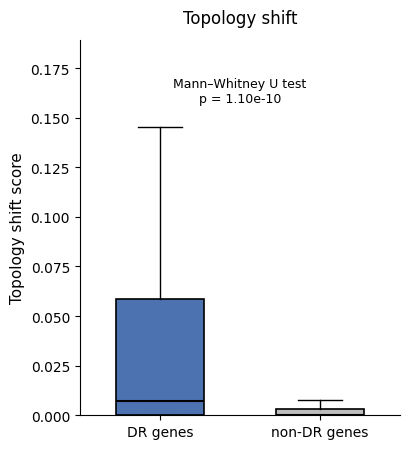

In [19]:
# Publication-style boxplot for topology shift comparison

topology_plot_df = comparison_df.copy()

topology_plot_df["group"] = np.where(
    topology_plot_df["is_DR_gene"],
    "DR genes",
    "non-DR genes"
)

dr_topology_values = topology_plot_df.loc[
    topology_plot_df["group"] == "DR genes",
    "topology_shift"
]

non_dr_topology_values = topology_plot_df.loc[
    topology_plot_df["group"] == "non-DR genes",
    "topology_shift"
]

fig, ax = plt.subplots(figsize=(4.2, 4.6))

box = ax.boxplot(
    [dr_topology_values, non_dr_topology_values],
    tick_labels=["DR genes", "non-DR genes"],
    showfliers=False,
    patch_artist=True,
    widths=0.55
)

# Colors
colors = ["#4C72B0", "#BDBDBD"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.0)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.0)

ax.set_ylabel("Topology shift score", fontsize=11)
ax.set_xlabel("")
ax.set_title("Topology shift", fontsize=12, pad=12)

y_max = topology_plot_df["topology_shift"].max()
ax.set_ylim(0, y_max * 1.25)

ax.text(
    1.5,
    y_max * 1.08,
    f"Mann–Whitney U test\np = {p_value:.2e}",
    ha="center",
    va="center",
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

plt.savefig(
    "figures/Figure_topology_shift_boxplot.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "figures/Figure_topology_shift_boxplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [20]:
n_dr = len(dr_shift)
n_non_dr = len(non_dr_shift)

rank_biserial = (2 * u_stat) / (n_dr * n_non_dr) - 1

print("Rank-biserial correlation:", rank_biserial)

summary_stats = pd.DataFrame({
    "group": ["DR genes", "non-DR genes"],
    "n": [n_dr, n_non_dr],
    "mean_topology_shift": [dr_shift.mean(), non_dr_shift.mean()],
    "median_topology_shift": [dr_shift.median(), non_dr_shift.median()],
    "std_topology_shift": [dr_shift.std(), non_dr_shift.std()]
})

display(summary_stats)

Rank-biserial correlation: 0.3673198146882357


,group,n,mean_topology_shift,median_topology_shift,std_topology_shift
0,DR genes,99,0.031099,0.007286,0.03751
1,non-DR genes,266,0.008034,0.000000,0.02066


In [21]:
test_summary = pd.DataFrame({
    "test": ["Mann-Whitney U"],
    "alternative": ["DR genes > non-DR genes"],
    "u_statistic": [u_stat],
    "p_value": [p_value],
    "rank_biserial_correlation": [rank_biserial],
    "n_DR_genes_excluding_RAC1": [n_dr],
    "n_non_DR_genes": [n_non_dr]
})

display(test_summary)

,test,alternative,u_statistic,p_value,rank_biserial_correlation,n_DR_genes_excluding_RAC1,n_non_DR_genes
0,Mann-Whitney U,DR genes > non-DR genes,18003.5,1.096639e-10,0.36732,99,266


In [22]:
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

topology_df.to_csv("results/RAC1_topology_shift_results.csv", index=False)
summary_stats.to_csv("results/RAC1_topology_shift_group_summary.csv", index=False)
test_summary.to_csv("results/RAC1_topology_shift_statistical_test.csv", index=False)

print("Saved results to results/")

Saved results to results/


In [23]:
# Exclude RAC1 for a stricter downstream view
top_shifted = (
    topology_df[topology_df["gene"] != "RAC1"]
    .sort_values("topology_shift", ascending=False)
    .head(20)
    .copy()
)

display(top_shifted[[
    "gene",
    "topology_shift",
    "is_DR_gene",
    "degree_centrality_delta",
    "strength_delta",
    "betweenness_delta",
    "clustering_delta"
]])

,gene,topology_shift,is_DR_gene,degree_centrality_delta,strength_delta,betweenness_delta,clustering_delta
70,PLAU,0.151445,True,0.002740,0.2465,0.000000,-0.025225
95,CDKN2A,0.145311,True,0.000000,-0.2620,0.001099,-0.003508
312,NAPSA,0.135166,True,-0.002740,-0.3570,-0.000948,0.002590
107,TUBA1B,0.116210,False,0.005479,0.4920,0.000000,-0.010726
72,SFTPD,0.115244,True,0.005479,0.4405,0.000000,-0.011150
125,ANXA1,0.107354,False,0.005479,0.4930,0.000015,-0.007286
128,HLA-DPA1,0.102280,True,0.002740,0.2460,0.000000,-0.015775
7,S100A2,0.092636,True,0.002740,0.2460,0.000000,-0.013801
320,CYR61,0.090750,False,0.002740,0.2465,0.000000,0.013403
241,IRF1,0.084007,False,0.002740,0.2465,0.000000,-0.011960


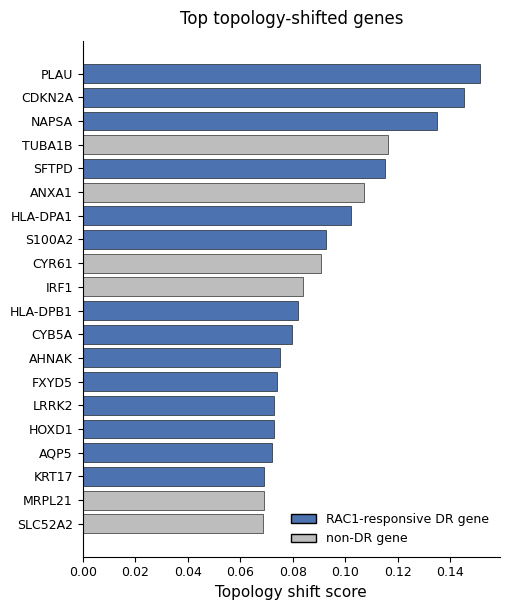

In [24]:
# Publication-style barplot for top topology-shifted genes

top_plot = top_shifted.iloc[::-1].copy()

bar_colors = [
    "#4C72B0" if is_dr else "#BDBDBD"
    for is_dr in top_plot["is_DR_gene"]
]

fig, ax = plt.subplots(figsize=(5.2, 6.2))

ax.barh(
    top_plot["gene"],
    top_plot["topology_shift"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.4
)

ax.set_xlabel("Topology shift score", fontsize=11)
ax.set_ylabel("")
ax.set_title("Top topology-shifted genes", fontsize=12, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=9)

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#4C72B0", edgecolor="black", label="RAC1-responsive DR gene"),
    Patch(facecolor="#BDBDBD", edgecolor="black", label="non-DR gene")
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=9,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_top_shifted_genes_barplot.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "figures/Figure_top_shifted_genes_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [25]:
n_top = len(top_shifted)
n_top_dr = top_shifted["is_DR_gene"].sum()
fraction_top_dr = n_top_dr / n_top

print("Top shifted genes:", n_top)
print("DR genes among top shifted genes:", n_top_dr)
print("Fraction of DR genes among top shifted genes:", fraction_top_dr)

display(top_shifted[["gene", "topology_shift", "is_DR_gene"]])

Top shifted genes: 20
DR genes among top shifted genes: 14
Fraction of DR genes among top shifted genes: 0.7


,gene,topology_shift,is_DR_gene
70,PLAU,0.151445,True
95,CDKN2A,0.145311,True
312,NAPSA,0.135166,True
107,TUBA1B,0.116210,False
72,SFTPD,0.115244,True
125,ANXA1,0.107354,False
128,HLA-DPA1,0.102280,True
7,S100A2,0.092636,True
320,CYR61,0.090750,False
241,IRF1,0.084007,False


In [26]:
from scipy.stats import fisher_exact, hypergeom

# Background numbers
total_genes = comparison_df.shape[0]          # 365 genes（excluding RAC1）
total_dr = comparison_df["is_DR_gene"].sum()      # 99 DR genes
total_non_dr = total_genes - total_dr         # 266 non-DR genes

# Top shifted genes
top_n = top_shifted.shape[0]                  # 20
top_dr = top_shifted["is_DR_gene"].sum()            # 14
top_non_dr = top_n - top_dr                  # 6

# Remaining genes
remaining_dr = total_dr - top_dr
remaining_non_dr = total_non_dr - top_non_dr

# 2x2 contingency table
contingency_table = [
    [top_dr, top_non_dr],
    [remaining_dr, remaining_non_dr]
]

odds_ratio, fisher_p = fisher_exact(
    contingency_table,
    alternative="greater"
)

# Hypergeometric test:
# Probability of observing at least top_dr DR genes among top_n genes
hypergeom_p = hypergeom.sf(
    top_dr - 1,
    total_genes,
    total_dr,
    top_n
)

print("Total genes excluding RAC1:", total_genes)
print("Total DR genes:", total_dr)
print("Total non-DR genes:", total_non_dr)

print("\nTop shifted genes:", top_n)
print("DR genes in top shifted genes:", top_dr)
print("Non-DR genes in top shifted genes:", top_non_dr)

print("\nBackground DR fraction:", total_dr / total_genes)
print("Top shifted DR fraction:", top_dr / top_n)

print("\nFisher exact test odds ratio:", odds_ratio)
print("Fisher exact test p value:", fisher_p)

print("\nHypergeometric enrichment p value:", hypergeom_p)

Total genes excluding RAC1: 365
Total DR genes: 99
Total non-DR genes: 266

Top shifted genes: 20
DR genes in top shifted genes: 14
Non-DR genes in top shifted genes: 6

Background DR fraction: 0.27123287671232876
Top shifted DR fraction: 0.7

Fisher exact test odds ratio: 7.137254901960785
Fisher exact test p value: 4.743727024856817e-05

Hypergeometric enrichment p value: 4.743727024856817e-05


In [27]:
top_shifted.to_csv("results/RAC1_top20_topology_shifted_genes.csv", index=False)

top_enrichment_summary = pd.DataFrame({
    "top_n": [top_n],
    "top_DR_genes": [top_dr],
    "top_non_DR_genes": [top_non_dr],
    "background_total_genes_excluding_RAC1": [total_genes],
    "background_DR_genes": [total_dr],
    "background_non_DR_genes": [total_non_dr],
    "background_DR_fraction": [total_dr / total_genes],
    "top_shifted_DR_fraction": [top_dr / top_n],
    "fisher_odds_ratio": [odds_ratio],
    "fisher_p_value": [fisher_p],
    "hypergeometric_p_value": [hypergeom_p]
})

top_enrichment_summary.to_csv(
    "results/RAC1_topology_shift_top20_DR_enrichment.csv",
    index=False
)

display(top_enrichment_summary)

,top_n,top_DR_genes,top_non_DR_genes,background_total_genes_excluding_RAC1,background_DR_genes,background_non_DR_genes,background_DR_fraction,top_shifted_DR_fraction,fisher_odds_ratio,fisher_p_value,hypergeometric_p_value
0,20,14,6,365,99,266,0.271233,0.7,7.137255,0.000047,0.000047


## 5. Adjacency-vector PCA graph representation shift

This section represents each gene by its full GRN adjacency vector, meaning that each gene is described by its weighted connection profile to all other genes in the network.

WT and RAC1-vKO gene vectors are jointly embedded using PCA. For each gene, the Euclidean distance between its WT and RAC1-vKO positions in the PCA graph representation space is calculated as the embedding shift distance.

This analysis asks whether RAC1-responsive DR genes occupy more shifted positions in the WT versus RAC1-vKO graph representation space.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Each row represents one gene's network connection profile
WT_repr = WT_mat.copy()
vKO_repr = vKO_mat.copy()

# Check shape
print("WT representation shape:", WT_repr.shape)
print("vKO representation shape:", vKO_repr.shape)

# Combine WT and vKO representations for joint embedding
combined_repr = pd.concat(
    [WT_repr, vKO_repr],
    axis=0
)

combined_labels = (
    ["WT"] * WT_repr.shape[0] +
    ["vKO"] * vKO_repr.shape[0]
)

combined_genes = list(WT_repr.index) + list(vKO_repr.index)

print("Combined representation shape:", combined_repr.shape)
print("Number of labels:", len(combined_labels))
print("Number of gene entries:", len(combined_genes))

WT representation shape: (366, 366)
vKO representation shape: (366, 366)
Combined representation shape: (732, 366)
Number of labels: 732
Number of gene entries: 732


In [29]:
# Standardize features before PCA
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_repr)

# PCA embedding
pca = PCA(n_components=10, random_state=123)
combined_pca = pca.fit_transform(combined_scaled)

print("PCA embedding shape:", combined_pca.shape)
print("Explained variance ratio of first 10 PCs:")
print(pca.explained_variance_ratio_)

print("Total explained variance by first 10 PCs:")
print(pca.explained_variance_ratio_.sum())

PCA embedding shape: (732, 10)
Explained variance ratio of first 10 PCs:
[4.11500299e-01 3.65753140e-01 2.09269900e-01 1.18400369e-03
 5.87391386e-04 3.46716780e-04 3.36634633e-04 1.88393977e-04
 1.65404891e-04 1.62371308e-04]
Total explained variance by first 10 PCs:
0.9894942561312148


In [30]:
embedding_df = pd.DataFrame(
    combined_pca,
    columns=[f"PC{i+1}" for i in range(combined_pca.shape[1])]
)

embedding_df["gene"] = combined_genes
embedding_df["condition"] = combined_labels

embedding_df["is_DR_gene"] = embedding_df["gene"].isin(dr_genes_no_rac1)
embedding_df["is_RAC1"] = embedding_df["gene"] == "RAC1"

display(embedding_df.head())
print(embedding_df["condition"].value_counts())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,gene,condition,is_DR_gene,is_RAC1
0,0.415207,-0.570739,-9.164897,0.165548,-0.044224,-0.002668,0.008605,-0.012305,-0.019921,-0.011862,IGF2,WT,False,False
1,-0.061166,-0.543865,-9.622860,0.212083,-0.070477,-0.017000,0.072457,0.013390,-0.008104,-0.009967,SCGB1A1,WT,False,False
2,-0.334601,0.121592,-9.050470,0.185727,-0.126859,0.022325,0.075651,0.026215,-0.015945,0.003533,KRT81,WT,False,False
3,15.970292,-0.270459,2.121708,-1.235419,0.104291,-0.117459,0.494143,-0.195051,0.020058,-0.089299,NTS,WT,False,False
4,0.476100,6.961245,-11.015409,0.178367,-0.965425,0.139978,0.080143,-0.175742,-0.008663,-0.003400,PSCA,WT,True,False


condition
WT     366
vKO    366
Name: count, dtype: int64


In [31]:
# Split WT and vKO embeddings
WT_emb = embedding_df[embedding_df["condition"] == "WT"].set_index("gene")
vKO_emb = embedding_df[embedding_df["condition"] == "vKO"].set_index("gene")

pc_cols = [f"PC{i+1}" for i in range(10)]

# Ensure same gene order
common_genes = list(WT_mat.index)

embedding_shift_records = []

for gene in common_genes:
    wt_vec = WT_emb.loc[gene, pc_cols].values
    vko_vec = vKO_emb.loc[gene, pc_cols].values

    shift_distance = np.linalg.norm(vko_vec - wt_vec)

    embedding_shift_records.append({
        "gene": gene,
        "embedding_shift": shift_distance,
        "is_DR_gene": gene in dr_genes_no_rac1,
        "is_RAC1": gene == "RAC1"
    })

embedding_shift_df = pd.DataFrame(embedding_shift_records)

embedding_shift_df_sorted = embedding_shift_df.sort_values(
    "embedding_shift",
    ascending=False
)

display(embedding_shift_df_sorted.head(20))

,gene,embedding_shift,is_DR_gene,is_RAC1
302,RAC1,14.399186,False,True
95,CDKN2A,2.594593,True,False
234,C19orf33,1.911284,True,False
144,MARCKS,1.886527,True,False
52,COL1A1,1.797400,True,False
62,KRT19,1.787497,True,False
152,HLA-B,1.772642,True,False
284,SFTPB,1.772642,True,False
312,NAPSA,1.752836,True,False
78,SFTPA2,1.703321,True,False


In [32]:
# Exclude RAC1
embedding_comparison_df = embedding_shift_df[
    embedding_shift_df["gene"] != "RAC1"
].copy()

dr_embedding_shift = embedding_comparison_df.loc[
    embedding_comparison_df["is_DR_gene"],
    "embedding_shift"
]

non_dr_embedding_shift = embedding_comparison_df.loc[
    ~embedding_comparison_df["is_DR_gene"],
    "embedding_shift"
]

print("Number of DR genes excluding RAC1:", len(dr_embedding_shift))
print("Number of non-DR genes:", len(non_dr_embedding_shift))

print("\nDR embedding shift summary:")
print(dr_embedding_shift.describe())

print("\nNon-DR embedding shift summary:")
print(non_dr_embedding_shift.describe())

emb_u_stat, emb_p_value = mannwhitneyu(
    dr_embedding_shift,
    non_dr_embedding_shift,
    alternative="greater"
)

emb_rank_biserial = (
    2 * emb_u_stat
) / (
    len(dr_embedding_shift) * len(non_dr_embedding_shift)
) - 1

print("\nMann-Whitney U statistic:", emb_u_stat)
print("P value:", emb_p_value)
print("Rank-biserial correlation:", emb_rank_biserial)

Number of DR genes excluding RAC1: 99
Number of non-DR genes: 266

DR embedding shift summary:
count    99.000000
mean      1.003907
std       0.476031
min       0.287188
25%       0.599133
50%       0.856612
75%       1.460697
max       2.594593
Name: embedding_shift, dtype: float64

Non-DR embedding shift summary:
count    266.000000
mean       0.244169
std        0.296472
min        0.000000
25%        0.039612
50%        0.148545
75%        0.320611
max        1.564678
Name: embedding_shift, dtype: float64

Mann-Whitney U statistic: 24606.5
P value: 1.3009482702665257e-37
Rank-biserial correlation: 0.8688007898534214


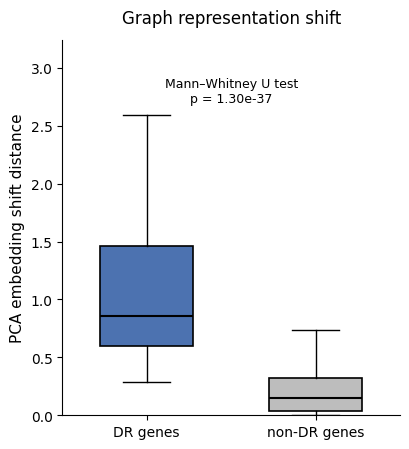

In [33]:
# Publication-style boxplot for PCA graph embedding shift comparison

embedding_plot_df = embedding_comparison_df.copy()

embedding_plot_df["group"] = np.where(
    embedding_plot_df["is_DR_gene"],
    "DR genes",
    "non-DR genes"
)

dr_emb_values = embedding_plot_df.loc[
    embedding_plot_df["group"] == "DR genes",
    "embedding_shift"
]

non_dr_emb_values = embedding_plot_df.loc[
    embedding_plot_df["group"] == "non-DR genes",
    "embedding_shift"
]

fig, ax = plt.subplots(figsize=(4.2, 4.6))

box = ax.boxplot(
    [dr_emb_values, non_dr_emb_values],
    tick_labels=["DR genes", "non-DR genes"],
    showfliers=False,
    patch_artist=True,
    widths=0.55
)

# Colors
colors = ["#4C72B0", "#BDBDBD"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.0)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.0)

ax.set_ylabel("PCA embedding shift distance", fontsize=11)
ax.set_xlabel("")
ax.set_title("Graph representation shift", fontsize=12, pad=12)

y_max = embedding_plot_df["embedding_shift"].max()
ax.set_ylim(0, y_max * 1.25)

ax.text(
    1.5,
    y_max * 1.08,
    f"Mann–Whitney U test\np = {emb_p_value:.2e}",
    ha="center",
    va="center",
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

plt.savefig(
    "figures/Figure_PCA_embedding_shift_boxplot.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "figures/Figure_PCA_embedding_shift_boxplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

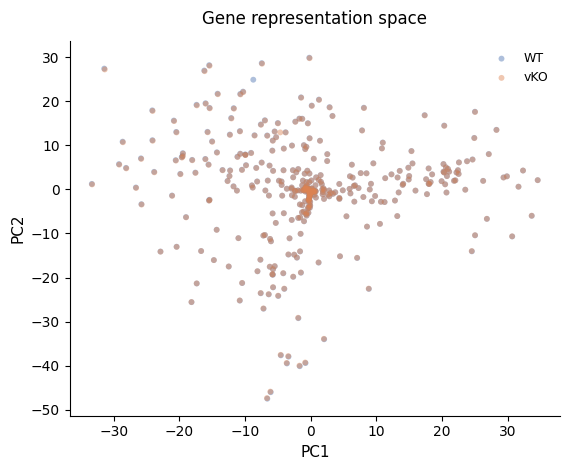

In [55]:
# Publication-style PCA gene representation space scatter plot

fig, ax = plt.subplots(figsize=(5.8, 4.8))

condition_colors = {
    "WT": "#4C72B0",
    "vKO": "#DD8452"
}

for condition in ["WT", "vKO"]:
    subset = embedding_df[embedding_df["condition"] == condition]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=condition,
        alpha=0.45,
        s=18,
        color=condition_colors[condition],
        edgecolors="none"
    )

ax.set_xlabel("PC1", fontsize=11)
ax.set_ylabel("PC2", fontsize=11)
ax.set_title("Gene representation space", fontsize=12, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

ax.legend(
    frameon=False,
    fontsize=9,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_PCA_gene_embedding_space.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "figures/Figure_PCA_gene_embedding_space.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [35]:
embedding_shift_df.to_csv(
    "results/RAC1_PCA_embedding_shift_results.csv",
    index=False
)

embedding_summary_stats = pd.DataFrame({
    "group": ["DR genes", "non-DR genes"],
    "n": [len(dr_embedding_shift), len(non_dr_embedding_shift)],
    "mean_embedding_shift": [
        dr_embedding_shift.mean(),
        non_dr_embedding_shift.mean()
    ],
    "median_embedding_shift": [
        dr_embedding_shift.median(),
        non_dr_embedding_shift.median()
    ],
    "std_embedding_shift": [
        dr_embedding_shift.std(),
        non_dr_embedding_shift.std()
    ]
})

embedding_test_summary = pd.DataFrame({
    "test": ["Mann-Whitney U"],
    "alternative": ["DR genes > non-DR genes"],
    "u_statistic": [emb_u_stat],
    "p_value": [emb_p_value],
    "rank_biserial_correlation": [emb_rank_biserial],
    "n_DR_genes_excluding_RAC1": [len(dr_embedding_shift)],
    "n_non_DR_genes": [len(non_dr_embedding_shift)]
})

embedding_summary_stats.to_csv(
    "results/RAC1_PCA_embedding_shift_group_summary.csv",
    index=False
)

embedding_test_summary.to_csv(
    "results/RAC1_PCA_embedding_shift_statistical_test.csv",
    index=False
)

display(embedding_summary_stats)
display(embedding_test_summary)

,group,n,mean_embedding_shift,median_embedding_shift,std_embedding_shift
0,DR genes,99,1.003907,0.856612,0.476031
1,non-DR genes,266,0.244169,0.148545,0.296472


,test,alternative,u_statistic,p_value,rank_biserial_correlation,n_DR_genes_excluding_RAC1,n_non_DR_genes
0,Mann-Whitney U,DR genes > non-DR genes,24606.5,1.300948e-37,0.868801,99,266


In [36]:
top_embedding_shifted = (
    embedding_shift_df[embedding_shift_df["gene"] != "RAC1"]
    .sort_values("embedding_shift", ascending=False)
    .head(20)
    .copy()
)

display(top_embedding_shifted)

,gene,embedding_shift,is_DR_gene,is_RAC1
95,CDKN2A,2.594593,True,False
234,C19orf33,1.911284,True,False
144,MARCKS,1.886527,True,False
52,COL1A1,1.797400,True,False
62,KRT19,1.787497,True,False
152,HLA-B,1.772642,True,False
284,SFTPB,1.772642,True,False
312,NAPSA,1.752836,True,False
78,SFTPA2,1.703321,True,False
80,SFTPA1,1.688466,True,False


In [37]:
top_emb_n = len(top_embedding_shifted)
top_emb_dr = top_embedding_shifted["is_DR_gene"].sum()
top_emb_non_dr = top_emb_n - top_emb_dr

print("Top embedding-shifted genes:", top_emb_n)
print("DR genes among top embedding-shifted genes:", top_emb_dr)
print("Non-DR genes among top embedding-shifted genes:", top_emb_non_dr)
print("Fraction of DR genes among top embedding-shifted genes:", top_emb_dr / top_emb_n)

display(top_embedding_shifted[["gene", "embedding_shift", "is_DR_gene"]])

Top embedding-shifted genes: 20
DR genes among top embedding-shifted genes: 19
Non-DR genes among top embedding-shifted genes: 1
Fraction of DR genes among top embedding-shifted genes: 0.95


,gene,embedding_shift,is_DR_gene
95,CDKN2A,2.594593,True
234,C19orf33,1.911284,True
144,MARCKS,1.886527,True
52,COL1A1,1.797400,True
62,KRT19,1.787497,True
152,HLA-B,1.772642,True
284,SFTPB,1.772642,True
312,NAPSA,1.752836,True
78,SFTPA2,1.703321,True
80,SFTPA1,1.688466,True


In [38]:
# Background numbers are same
total_genes = embedding_comparison_df.shape[0]
total_dr = embedding_comparison_df["is_DR_gene"].sum()
total_non_dr = total_genes - total_dr

# Top embedding-shifted genes
top_n = top_embedding_shifted.shape[0]
top_dr = top_embedding_shifted["is_DR_gene"].sum()
top_non_dr = top_n - top_dr

remaining_dr = total_dr - top_dr
remaining_non_dr = total_non_dr - top_non_dr

embedding_contingency_table = [
    [top_dr, top_non_dr],
    [remaining_dr, remaining_non_dr]
]

emb_odds_ratio, emb_fisher_p = fisher_exact(
    embedding_contingency_table,
    alternative="greater"
)

emb_hypergeom_p = hypergeom.sf(
    top_dr - 1,
    total_genes,
    total_dr,
    top_n
)

print("Total genes excluding RAC1:", total_genes)
print("Total DR genes:", total_dr)
print("Total non-DR genes:", total_non_dr)

print("\nTop embedding-shifted genes:", top_n)
print("DR genes in top embedding-shifted genes:", top_dr)
print("Non-DR genes in top embedding-shifted genes:", top_non_dr)

print("\nBackground DR fraction:", total_dr / total_genes)
print("Top embedding-shifted DR fraction:", top_dr / top_n)

print("\nFisher exact test odds ratio:", emb_odds_ratio)
print("Fisher exact test p value:", emb_fisher_p)

print("\nHypergeometric enrichment p value:", emb_hypergeom_p)

Total genes excluding RAC1: 365
Total DR genes: 99
Total non-DR genes: 266

Top embedding-shifted genes: 20
DR genes in top embedding-shifted genes: 19
Non-DR genes in top embedding-shifted genes: 1

Background DR fraction: 0.27123287671232876
Top embedding-shifted DR fraction: 0.95

Fisher exact test odds ratio: 62.9375
Fisher exact test p value: 6.792356424133487e-11

Hypergeometric enrichment p value: 6.792356424133487e-11


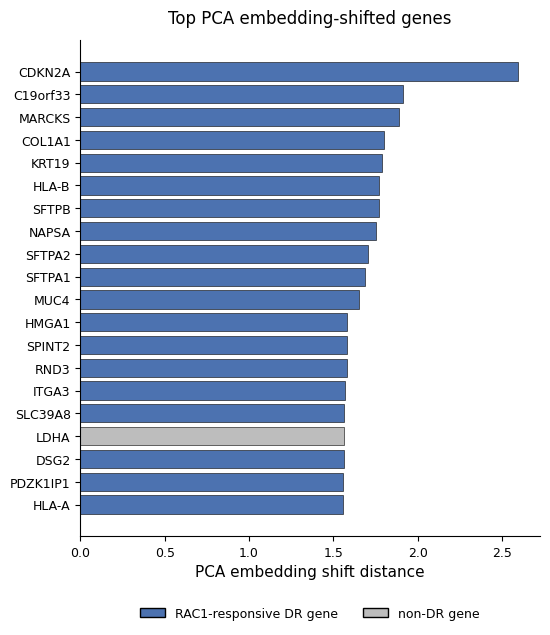

In [58]:
# Publication-style barplot for top PCA embedding-shifted genes

top_emb_plot = top_embedding_shifted.iloc[::-1].copy()

bar_colors = [
    "#4C72B0" if is_dr else "#BDBDBD"
    for is_dr in top_emb_plot["is_DR_gene"]
]

fig, ax = plt.subplots(figsize=(5.6, 6.4))

ax.barh(
    top_emb_plot["gene"],
    top_emb_plot["embedding_shift"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.4
)

ax.set_xlabel("PCA embedding shift distance", fontsize=11)
ax.set_ylabel("")
ax.set_title("Top PCA embedding-shifted genes", fontsize=12, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=9)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#4C72B0", edgecolor="black", label="RAC1-responsive DR gene"),
    Patch(facecolor="#BDBDBD", edgecolor="black", label="non-DR gene")
]

# Put legend below the plot, not inside the plotting area
ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

plt.subplots_adjust(bottom=0.18)
plt.tight_layout()

plt.savefig(
    "figures/Figure_top_embedding_shifted_genes_barplot.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "figures/Figure_top_embedding_shifted_genes_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [40]:
top_embedding_shifted.to_csv(
    "results/RAC1_top20_PCA_embedding_shifted_genes.csv",
    index=False
)

embedding_top_enrichment_summary = pd.DataFrame({
    "top_n": [top_n],
    "top_DR_genes": [top_dr],
    "top_non_DR_genes": [top_non_dr],
    "background_total_genes_excluding_RAC1": [total_genes],
    "background_DR_genes": [total_dr],
    "background_non_DR_genes": [total_non_dr],
    "background_DR_fraction": [total_dr / total_genes],
    "top_embedding_shifted_DR_fraction": [top_dr / top_n],
    "fisher_odds_ratio": [emb_odds_ratio],
    "fisher_p_value": [emb_fisher_p],
    "hypergeometric_p_value": [emb_hypergeom_p]
})

embedding_top_enrichment_summary.to_csv(
    "results/RAC1_PCA_embedding_shift_top20_DR_enrichment.csv",
    index=False
)

display(embedding_top_enrichment_summary)

,top_n,top_DR_genes,top_non_DR_genes,background_total_genes_excluding_RAC1,background_DR_genes,background_non_DR_genes,background_DR_fraction,top_embedding_shifted_DR_fraction,fisher_odds_ratio,fisher_p_value,hypergeometric_p_value
0,20,19,1,365,99,266,0.271233,0.95,62.9375,6.792356e-11,6.792356e-11


## 6. Aligned node2vec embedding shift validation

This section uses node2vec to learn graph embeddings from WT and RAC1-vKO GRNs.

Because node2vec embeddings trained separately on two graphs can differ by arbitrary rotation or reflection, RAC1-vKO embeddings are aligned to WT embeddings using orthogonal Procrustes alignment before calculating node-level embedding shift distances.

This analysis provides a random-walk-based graph representation sensitivity check for the PCA-based embedding result.

In [41]:
!pip -q install node2vec

from node2vec import Node2Vec
from scipy.linalg import orthogonal_procrustes

print("node2vec imported successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy

In [42]:
def run_node2vec_embedding(G, graph_name, dimensions=16, walk_length=10, num_walks=100):
    """
    Run node2vec on a weighted NetworkX graph.
    """
    node2vec = Node2Vec(
        G,
        dimensions=dimensions,
        walk_length=walk_length,
        num_walks=num_walks,
        workers=1,
        weight_key="abs_weight",
        seed=123,
        quiet=True
    )

    model = node2vec.fit(
        window=5,
        min_count=1,
        batch_words=4,
        seed=123
    )

    genes = list(G.nodes())
    emb = np.vstack([model.wv[gene] for gene in genes])

    emb_df = pd.DataFrame(
        emb,
        columns=[f"N2V{i+1}" for i in range(dimensions)]
    )
    emb_df["gene"] = genes
    emb_df["graph"] = graph_name

    return emb_df


WT_n2v = run_node2vec_embedding(WT_graph, "WT")
vKO_n2v = run_node2vec_embedding(vKO_graph, "vKO")

display(WT_n2v.head())
display(vKO_n2v.head())

print("WT node2vec shape:", WT_n2v.shape)
print("vKO node2vec shape:", vKO_n2v.shape)

,N2V1,N2V2,N2V3,N2V4,N2V5,N2V6,N2V7,N2V8,N2V9,N2V10,N2V11,N2V12,N2V13,N2V14,N2V15,N2V16,gene,graph
0,-0.030886,0.015383,-0.026715,-0.034133,0.053833,0.012823,-0.024949,-0.052510,-0.056942,-0.028052,0.019703,0.029545,-0.002723,-0.022905,0.017371,-0.013920,IGF2,WT
1,0.057039,-0.029783,-0.033661,0.030605,0.024007,-0.062271,-0.025208,-0.047431,-0.030648,-0.026025,-0.059572,0.053413,0.056908,-0.022313,-0.004724,0.003883,SCGB1A1,WT
2,-0.030325,-0.045957,-0.013369,0.002657,0.001058,-0.043169,-0.018229,-0.054954,0.001244,-0.033634,0.043909,0.010426,-0.014105,-0.021110,0.047197,-0.035620,KRT81,WT
3,-0.537195,-0.548200,0.416506,0.791161,-0.992547,-0.396800,0.943396,0.918203,-0.022988,0.367563,-0.078529,-0.517390,-1.284292,0.584379,0.525847,-0.173622,NTS,WT
4,-0.025860,0.033245,0.051320,0.020686,0.048115,-0.037661,-0.043381,0.030246,-0.040222,0.041083,-0.044550,-0.004829,-0.029815,-0.009301,0.060009,-0.002139,PSCA,WT


,N2V1,N2V2,N2V3,N2V4,N2V5,N2V6,N2V7,N2V8,N2V9,N2V10,N2V11,N2V12,N2V13,N2V14,N2V15,N2V16,gene,graph
0,-0.035786,-0.048899,-0.031888,0.053659,0.008372,-0.047895,-0.056937,0.013884,0.014207,0.055618,0.031255,-0.035457,-0.037151,-0.045236,-0.009958,-0.033507,IGF2,vKO
1,-0.010493,-0.003445,-0.012960,-0.011835,-0.002614,-0.037611,-0.034396,-0.023297,0.031466,0.028764,-0.027453,0.018110,-0.003182,-0.060160,-0.040542,-0.056179,SCGB1A1,vKO
2,-0.022878,0.017424,-0.001514,-0.015316,-0.057164,0.004273,-0.004308,0.000990,0.005375,-0.039845,0.030459,0.030559,0.008918,0.024509,-0.040047,-0.014403,KRT81,vKO
3,-0.175288,-0.017827,1.002725,0.669875,-1.155537,0.075041,0.686567,-0.509430,0.308999,-0.477383,-0.497095,-0.625029,-0.799517,0.606044,-0.499861,0.374530,NTS,vKO
4,-0.039856,0.042176,-0.056562,0.032925,-0.041263,0.033554,-0.048015,-0.055617,-0.011095,0.058531,-0.006192,-0.031895,0.053496,0.001473,0.035695,-0.050333,PSCA,vKO


WT node2vec shape: (366, 18)
vKO node2vec shape: (366, 18)


In [43]:
# Prepare matrices
n2v_cols = [f"N2V{i+1}" for i in range(16)]

gene_order = list(WT_mat.index)

WT_n2v_mat = (
    WT_n2v.set_index("gene")
    .loc[gene_order, n2v_cols]
    .values
)

vKO_n2v_mat = (
    vKO_n2v.set_index("gene")
    .loc[gene_order, n2v_cols]
    .values
)

# Align vKO embedding space to WT embedding space
rotation_matrix, scale = orthogonal_procrustes(
    vKO_n2v_mat,
    WT_n2v_mat
)

vKO_n2v_aligned = vKO_n2v_mat @ rotation_matrix

print("WT node2vec matrix:", WT_n2v_mat.shape)
print("vKO aligned node2vec matrix:", vKO_n2v_aligned.shape)
print("Procrustes scale:", scale)

WT node2vec matrix: (366, 16)
vKO aligned node2vec matrix: (366, 16)
Procrustes scale: 1225.8761


In [44]:
node2vec_shift = np.linalg.norm(
    vKO_n2v_aligned - WT_n2v_mat,
    axis=1
)

node2vec_shift_df = pd.DataFrame({
    "gene": gene_order,
    "node2vec_shift": node2vec_shift
})

node2vec_shift_df["is_DR_gene"] = node2vec_shift_df["gene"].isin(dr_genes_no_rac1)
node2vec_shift_df["is_RAC1"] = node2vec_shift_df["gene"] == "RAC1"

node2vec_shift_df_sorted = node2vec_shift_df.sort_values(
    "node2vec_shift",
    ascending=False
)

display(node2vec_shift_df_sorted.head(20))

,gene,node2vec_shift,is_DR_gene,is_RAC1
302,RAC1,1.546998,False,True
214,TMSB10,1.074527,True,False
95,CDKN2A,0.935045,True,False
320,CYR61,0.933972,False,False
311,NDUFA12,0.917936,False,False
272,RAN,0.914230,False,False
274,TUBB4B,0.902756,False,False
109,CKS1B,0.888911,False,False
296,EPHX1,0.881930,False,False
21,CST6,0.862156,True,False


In [45]:
node2vec_comparison_df = node2vec_shift_df[
    node2vec_shift_df["gene"] != "RAC1"
].copy()

dr_node2vec_shift = node2vec_comparison_df.loc[
    node2vec_comparison_df["is_DR_gene"],
    "node2vec_shift"
]

non_dr_node2vec_shift = node2vec_comparison_df.loc[
    ~node2vec_comparison_df["is_DR_gene"],
    "node2vec_shift"
]

print("Number of DR genes excluding RAC1:", len(dr_node2vec_shift))
print("Number of non-DR genes:", len(non_dr_node2vec_shift))

print("\nDR node2vec shift summary:")
print(dr_node2vec_shift.describe())

print("\nNon-DR node2vec shift summary:")
print(non_dr_node2vec_shift.describe())

n2v_u_stat, n2v_p_value = mannwhitneyu(
    dr_node2vec_shift,
    non_dr_node2vec_shift,
    alternative="greater"
)

n2v_rank_biserial = (
    2 * n2v_u_stat
) / (
    len(dr_node2vec_shift) * len(non_dr_node2vec_shift)
) - 1

print("\nMann-Whitney U statistic:", n2v_u_stat)
print("P value:", n2v_p_value)
print("Rank-biserial correlation:", n2v_rank_biserial)

Number of DR genes excluding RAC1: 99
Number of non-DR genes: 266

DR node2vec shift summary:
count    99.000000
mean      0.510251
std       0.184405
min       0.129458
25%       0.423567
50%       0.513932
75%       0.626714
max       1.074527
Name: node2vec_shift, dtype: float64

Non-DR node2vec shift summary:
count    266.000000
mean       0.352401
std        0.197771
min        0.074286
25%        0.198226
50%        0.232779
75%        0.528789
max        0.933972
Name: node2vec_shift, dtype: float64

Mann-Whitney U statistic: 18574.0
P value: 8.064803767168849e-10
Rank-biserial correlation: 0.4106478317004634


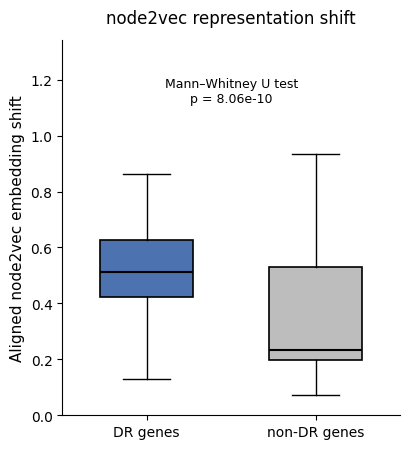

In [46]:
# Publication-style boxplot for aligned node2vec embedding shift comparison

node2vec_plot_df = node2vec_comparison_df.copy()

node2vec_plot_df["group"] = np.where(
    node2vec_plot_df["is_DR_gene"],
    "DR genes",
    "non-DR genes"
)

dr_n2v_values = node2vec_plot_df.loc[
    node2vec_plot_df["group"] == "DR genes",
    "node2vec_shift"
]

non_dr_n2v_values = node2vec_plot_df.loc[
    node2vec_plot_df["group"] == "non-DR genes",
    "node2vec_shift"
]

fig, ax = plt.subplots(figsize=(4.2, 4.6))

box = ax.boxplot(
    [dr_n2v_values, non_dr_n2v_values],
    tick_labels=["DR genes", "non-DR genes"],
    showfliers=False,
    patch_artist=True,
    widths=0.55
)

# Colors
colors = ["#4C72B0", "#BDBDBD"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.0)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.0)

ax.set_ylabel("Aligned node2vec embedding shift", fontsize=11)
ax.set_xlabel("")
ax.set_title("node2vec representation shift", fontsize=12, pad=12)

y_max = node2vec_plot_df["node2vec_shift"].max()
ax.set_ylim(0, y_max * 1.25)

ax.text(
    1.5,
    y_max * 1.08,
    f"Mann–Whitney U test\np = {n2v_p_value:.2e}",
    ha="center",
    va="center",
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

plt.savefig(
    "figures/Figure_node2vec_embedding_shift_boxplot.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "figures/Figure_node2vec_embedding_shift_boxplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [47]:
node2vec_shift_df.to_csv(
    "results/RAC1_node2vec_embedding_shift_results.csv",
    index=False
)

node2vec_summary_stats = pd.DataFrame({
    "group": ["DR genes", "non-DR genes"],
    "n": [len(dr_node2vec_shift), len(non_dr_node2vec_shift)],
    "mean_node2vec_shift": [
        dr_node2vec_shift.mean(),
        non_dr_node2vec_shift.mean()
    ],
    "median_node2vec_shift": [
        dr_node2vec_shift.median(),
        non_dr_node2vec_shift.median()
    ],
    "std_node2vec_shift": [
        dr_node2vec_shift.std(),
        non_dr_node2vec_shift.std()
    ]
})

node2vec_test_summary = pd.DataFrame({
    "test": ["Mann-Whitney U"],
    "alternative": ["DR genes > non-DR genes"],
    "u_statistic": [n2v_u_stat],
    "p_value": [n2v_p_value],
    "rank_biserial_correlation": [n2v_rank_biserial],
    "n_DR_genes_excluding_RAC1": [len(dr_node2vec_shift)],
    "n_non_DR_genes": [len(non_dr_node2vec_shift)]
})

node2vec_summary_stats.to_csv(
    "results/RAC1_node2vec_shift_group_summary.csv",
    index=False
)

node2vec_test_summary.to_csv(
    "results/RAC1_node2vec_shift_statistical_test.csv",
    index=False
)

display(node2vec_summary_stats)
display(node2vec_test_summary)

,group,n,mean_node2vec_shift,median_node2vec_shift,std_node2vec_shift
0,DR genes,99,0.510251,0.513932,0.184405
1,non-DR genes,266,0.352401,0.232779,0.197771


,test,alternative,u_statistic,p_value,rank_biserial_correlation,n_DR_genes_excluding_RAC1,n_non_DR_genes
0,Mann-Whitney U,DR genes > non-DR genes,18574.0,8.064804e-10,0.410648,99,266


In [48]:
top_node2vec_shifted = (
    node2vec_shift_df[node2vec_shift_df["gene"] != "RAC1"]
    .sort_values("node2vec_shift", ascending=False)
    .head(20)
    .copy()
)

display(top_node2vec_shifted)

# Background gene
total_genes = node2vec_comparison_df.shape[0]
total_dr = node2vec_comparison_df["is_DR_gene"].sum()
total_non_dr = total_genes - total_dr

# Top node2vec-shifted genes
top_n = top_node2vec_shifted.shape[0]
top_dr = top_node2vec_shifted["is_DR_gene"].sum()
top_non_dr = top_n - top_dr

remaining_dr = total_dr - top_dr
remaining_non_dr = total_non_dr - top_non_dr

node2vec_contingency_table = [
    [top_dr, top_non_dr],
    [remaining_dr, remaining_non_dr]
]

n2v_odds_ratio, n2v_fisher_p = fisher_exact(
    node2vec_contingency_table,
    alternative="greater"
)

n2v_hypergeom_p = hypergeom.sf(
    top_dr - 1,
    total_genes,
    total_dr,
    top_n
)

print("Total genes excluding RAC1:", total_genes)
print("Total DR genes:", total_dr)
print("Total non-DR genes:", total_non_dr)

print("\nTop node2vec-shifted genes:", top_n)
print("DR genes in top node2vec-shifted genes:", top_dr)
print("Non-DR genes in top node2vec-shifted genes:", top_non_dr)

print("\nBackground DR fraction:", total_dr / total_genes)
print("Top node2vec-shifted DR fraction:", top_dr / top_n)

print("\nFisher exact test odds ratio:", n2v_odds_ratio)
print("Fisher exact test p value:", n2v_fisher_p)

print("\nHypergeometric enrichment p value:", n2v_hypergeom_p)

,gene,node2vec_shift,is_DR_gene,is_RAC1
214,TMSB10,1.074527,True,False
95,CDKN2A,0.935045,True,False
320,CYR61,0.933972,False,False
311,NDUFA12,0.917936,False,False
272,RAN,0.914230,False,False
274,TUBB4B,0.902756,False,False
109,CKS1B,0.888911,False,False
296,EPHX1,0.881930,False,False
21,CST6,0.862156,True,False
175,HLA-A,0.799182,True,False


Total genes excluding RAC1: 365
Total DR genes: 99
Total non-DR genes: 266

Top node2vec-shifted genes: 20
DR genes in top node2vec-shifted genes: 11
Non-DR genes in top node2vec-shifted genes: 9

Background DR fraction: 0.27123287671232876
Top node2vec-shifted DR fraction: 0.55

Fisher exact test odds ratio: 3.5694444444444446
Fisher exact test p value: 0.006250652874245941

Hypergeometric enrichment p value: 0.006250652874245941


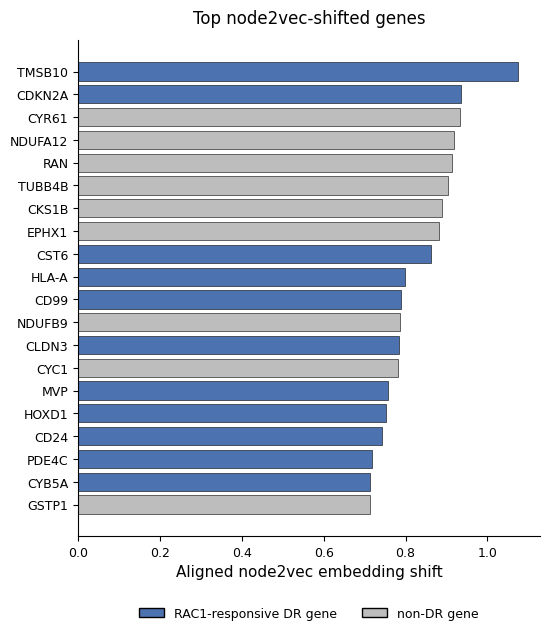

In [59]:
# Publication-style barplot for top node2vec-shifted genes

top_n2v_plot = top_node2vec_shifted.iloc[::-1].copy()

bar_colors = [
    "#4C72B0" if is_dr else "#BDBDBD"
    for is_dr in top_n2v_plot["is_DR_gene"]
]

fig, ax = plt.subplots(figsize=(5.6, 6.4))

ax.barh(
    top_n2v_plot["gene"],
    top_n2v_plot["node2vec_shift"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.4
)

ax.set_xlabel("Aligned node2vec embedding shift", fontsize=11)
ax.set_ylabel("")
ax.set_title("Top node2vec-shifted genes", fontsize=12, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=9)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#4C72B0", edgecolor="black", label="RAC1-responsive DR gene"),
    Patch(facecolor="#BDBDBD", edgecolor="black", label="non-DR gene")
]

# Put legend below the plot, not inside the plotting area
ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

plt.subplots_adjust(bottom=0.18)
plt.tight_layout()

plt.savefig(
    "figures/Figure_top_node2vec_shifted_genes_barplot.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "figures/Figure_top_node2vec_shifted_genes_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [50]:
top_node2vec_shifted.to_csv(
    "results/RAC1_top20_node2vec_shifted_genes.csv",
    index=False
)

node2vec_top_enrichment_summary = pd.DataFrame({
    "top_n": [top_n],
    "top_DR_genes": [top_dr],
    "top_non_DR_genes": [top_non_dr],
    "background_total_genes_excluding_RAC1": [total_genes],
    "background_DR_genes": [total_dr],
    "background_non_DR_genes": [total_non_dr],
    "background_DR_fraction": [total_dr / total_genes],
    "top_node2vec_shifted_DR_fraction": [top_dr / top_n],
    "fisher_odds_ratio": [n2v_odds_ratio],
    "fisher_p_value": [n2v_fisher_p],
    "hypergeometric_p_value": [n2v_hypergeom_p]
})

node2vec_top_enrichment_summary.to_csv(
    "results/RAC1_node2vec_shift_top20_DR_enrichment.csv",
    index=False
)

display(node2vec_top_enrichment_summary)

,top_n,top_DR_genes,top_non_DR_genes,background_total_genes_excluding_RAC1,background_DR_genes,background_non_DR_genes,background_DR_fraction,top_node2vec_shifted_DR_fraction,fisher_odds_ratio,fisher_p_value,hypergeometric_p_value
0,20,11,9,365,99,266,0.271233,0.55,3.569444,0.006251,0.006251


## 7. Final validation summary

This section summarizes the three graph-based validation layers:

1. Network topology shift  
2. Adjacency-vector PCA embedding shift  
3. Aligned node2vec embedding shift  

The final summary table reports median shifts in DR and non-DR genes, Mann–Whitney U test p values, rank-biserial effect sizes, and top-20 DR gene enrichment results.

Together, these results evaluate whether RAC1-responsive DR genes show stronger network-role and graph-representation shifts between WT and RAC1-vKO GRN spaces.

In [51]:
final_validation_summary = pd.DataFrame({
    "validation_layer": [
        "Network topology shift",
        "Adjacency-vector PCA embedding shift",
        "Aligned node2vec embedding shift"
    ],
    "DR_median_shift": [
        dr_shift.median(),
        dr_embedding_shift.median(),
        dr_node2vec_shift.median()
    ],
    "nonDR_median_shift": [
        non_dr_shift.median(),
        non_dr_embedding_shift.median(),
        non_dr_node2vec_shift.median()
    ],
    "mannwhitney_p_value": [
        p_value,
        emb_p_value,
        n2v_p_value
    ],
    "rank_biserial_correlation": [
        rank_biserial,
        emb_rank_biserial,
        n2v_rank_biserial
    ],
    "top20_DR_fraction": [
        top_enrichment_summary.loc[0, "top_shifted_DR_fraction"],
        embedding_top_enrichment_summary.loc[0, "top_embedding_shifted_DR_fraction"],
        node2vec_top_enrichment_summary.loc[0, "top_node2vec_shifted_DR_fraction"]
    ],
    "top20_enrichment_p_value": [
        top_enrichment_summary.loc[0, "fisher_p_value"],
        embedding_top_enrichment_summary.loc[0, "fisher_p_value"],
        node2vec_top_enrichment_summary.loc[0, "fisher_p_value"]
    ]
})

final_validation_summary.to_csv(
    "results/RAC1_python_graph_validation_final_summary.csv",
    index=False
)

display(final_validation_summary)

,validation_layer,DR_median_shift,nonDR_median_shift,mannwhitney_p_value,rank_biserial_correlation,top20_DR_fraction,top20_enrichment_p_value
0,Network topology shift,0.007286,0.000000,1.096639e-10,0.367320,0.70,4.743727e-05
1,Adjacency-vector PCA embedding shift,0.856612,0.148545,1.300948e-37,0.868801,0.95,6.792356e-11
2,Aligned node2vec embedding shift,0.513932,0.232779,8.064804e-10,0.410648,0.55,6.250653e-03


In [52]:
print("Figures:")
for f in os.listdir("figures"):
    print(" -", f)

print("\nResults:")
for f in os.listdir("results"):
    print(" -", f)

Figures:
 - Figure_PCA_gene_embedding_space.png
 - Figure_PCA_gene_embedding_space.pdf
 - Figure_top_node2vec_shifted_genes_barplot.pdf
 - Figure_node2vec_embedding_shift_boxplot.png
 - Figure_top_shifted_genes_barplot.pdf
 - Figure_top_node2vec_shifted_genes_barplot.png
 - Figure_topology_shift_boxplot.png
 - Figure_top_shifted_genes_barplot.png
 - Figure_PCA_embedding_shift_boxplot.pdf
 - Figure_top_embedding_shifted_genes_barplot.pdf
 - Figure_PCA_embedding_shift_boxplot.png
 - Figure_top_embedding_shifted_genes_barplot.png
 - Figure_topology_shift_boxplot.pdf
 - Figure_node2vec_embedding_shift_boxplot.pdf

Results:
 - RAC1_topology_shift_results.csv
 - RAC1_node2vec_shift_group_summary.csv
 - RAC1_PCA_embedding_shift_group_summary.csv
 - RAC1_topology_shift_top20_DR_enrichment.csv
 - RAC1_node2vec_shift_top20_DR_enrichment.csv
 - RAC1_topology_shift_group_summary.csv
 - RAC1_PCA_embedding_shift_top20_DR_enrichment.csv
 - RAC1_node2vec_embedding_shift_results.csv
 - RAC1_top20_PCA_e

In [60]:
import zipfile

zip_filename = "RAC1_python_graph_validation_results_figures.zip"

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    for folder in ["figures", "results"]:
        for root, dirs, files in os.walk(folder):
            for file in files:
                file_path = os.path.join(root, file)
                zipf.write(file_path)

print("Created:", zip_filename)

Created: RAC1_python_graph_validation_results_figures.zip


In [61]:
from google.colab import files

files.download("RAC1_python_graph_validation_results_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>